In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
MAHONY_ACCEL_REJECTION_GAIN = 1000.0

EXPECTED_COLUMNS = [
    "sample_index",
    "timestamp_ms",
    "accel_x_raw",
    "accel_y_raw",
    "accel_z_raw",
    "gyro_x_raw",
    "gyro_y_raw",
    "gyro_z_raw",
    "accel_x_g",
    "accel_y_g",
    "accel_z_g",
    "gyro_x_dps",
    "gyro_y_dps",
    "gyro_z_dps",
    "roll_acc_deg",
    "pitch_acc_deg",
    "accel_magnitude_g",
    "roll_kf_deg",
    "pitch_kf_deg",
    "roll_bias_dps",
    "pitch_bias_dps",
    "roll_k_angle",
    "pitch_k_angle",
    "qw",
    "qx",
    "qy",
    "qz",
    "mahony_roll_deg",
    "mahony_pitch_deg",
    "mahony_yaw_deg",
]

In [25]:
def validate_onboard_columns(df):
    """
    Verify that the CSV contains the complete 30-field STM32 telemetry packet.
    """

    missing_columns = [
        column
        for column in EXPECTED_COLUMNS
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            "CSV is missing required onboard telemetry columns: "
            + ", ".join(missing_columns)
        )

    if len(df) == 0:
        raise ValueError("CSV contains no samples.")

    return df


In [26]:
def process_imu_data(
    filepath,
    max_rows=None,
    mahony_accel_rejection_gain=MAHONY_ACCEL_REJECTION_GAIN
):
    """
    Load STM32 telemetry and prepare onboard estimator results for analysis.

    The STM32 has already calculated:
        - accelerometer roll and pitch
        - adaptive two-state Kalman roll and pitch
        - Kalman gyro-bias estimates
        - Kalman angle gains
        - Mahony quaternion orientation
        - Mahony roll, pitch, and yaw

    Pure gyroscope integration and diagnostic signals are reconstructed here
    only to provide comparison plots.
    """

    df = pd.read_csv(filepath)
    validate_onboard_columns(df)

    if max_rows is not None:
        df = df.iloc[:max_rows].copy()
    else:
        df = df.copy()

    # Make sure every required telemetry field is numeric.
    df[EXPECTED_COLUMNS] = df[EXPECTED_COLUMNS].apply(
        pd.to_numeric,
        errors="raise"
    )

    # Start time at zero.
    df["time_s"] = (
        df["timestamp_ms"] - df["timestamp_ms"].iloc[0]
    ) / 1000.0

    # Time elapsed since the previous sample.
    df["dt_s"] = np.diff(
        df["time_s"],
        prepend=df["time_s"].iloc[0]
    )

    # Aliases preserve the structure and naming of the post-processing notebook.
    df["gx_dps"] = df["gyro_x_dps"]
    df["gy_dps"] = df["gyro_y_dps"]
    df["gz_dps"] = df["gyro_z_dps"]

    df["accel_mag_g"] = df["accel_magnitude_g"]

    df["roll_kf_adaptive_deg"] = df["roll_kf_deg"]
    df["pitch_kf_adaptive_deg"] = df["pitch_kf_deg"]

    df["roll_bias_adaptive_dps"] = df["roll_bias_dps"]
    df["pitch_bias_adaptive_dps"] = df["pitch_bias_dps"]

    df["roll_gain_kf"] = df["roll_k_angle"]
    df["pitch_gain_kf"] = df["pitch_k_angle"]

    df["roll_mahony_deg"] = df["mahony_roll_deg"]
    df["pitch_mahony_deg"] = df["mahony_pitch_deg"]
    df["yaw_mahony_deg"] = df["mahony_yaw_deg"]

    # Gyroscope-only orientation, reconstructed for comparison.
    df["roll_gyro_deg"] = (
        df["roll_acc_deg"].iloc[0]
        + np.cumsum(df["gx_dps"] * df["dt_s"])
    )

    df["pitch_gyro_deg"] = (
        df["pitch_acc_deg"].iloc[0]
        + np.cumsum(df["gy_dps"] * df["dt_s"])
    )

    # Reconstruct the adaptive Mahony accelerometer-feedback weight.
    accel_deviation_g = df["accel_mag_g"] - 1.0

    df["mahony_accel_weight"] = (
        1.0
        / (
            1.0
            + mahony_accel_rejection_gain
            * accel_deviation_g**2
        )
    )

    # Quaternion normalization diagnostics.
    df["quaternion_norm"] = np.sqrt(
        df["qw"]**2
        + df["qx"]**2
        + df["qy"]**2
        + df["qz"]**2
    )

    df["quaternion_norm_error"] = (
        df["quaternion_norm"] - 1.0
    )

    return df


In [27]:
def plot_kalman_bias_estimates(df, experiment_name, skip_seconds=0.0):
    plot_df = df.loc[df["time_s"] >= skip_seconds]

    plt.figure(figsize=(12, 5))

    plt.plot(
        plot_df["time_s"],
        plot_df["roll_bias_adaptive_dps"],
        label="STM32 roll-axis bias estimate"
    )

    plt.plot(
        plot_df["time_s"],
        plot_df["pitch_bias_adaptive_dps"],
        label="STM32 pitch-axis bias estimate"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Gyroscope bias (degrees/s)")
    plt.title(f"{experiment_name}: STM32 Kalman Gyroscope Bias Estimates")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


In [28]:
STATIC_FILE = "Live Data/Roll Pitch Data.csv"
SHAKE_FILE = "Live Data/Shake Test.csv"
HOLD_FILE = "Live Data/Long Hold.csv"

static_df = process_imu_data(
    STATIC_FILE,
    max_rows=8001
)

shake_df = process_imu_data(
    SHAKE_FILE
)

hold_df = process_imu_data(
    HOLD_FILE
)


## Static Orientation Test
IMU is rotated to various orientations and held

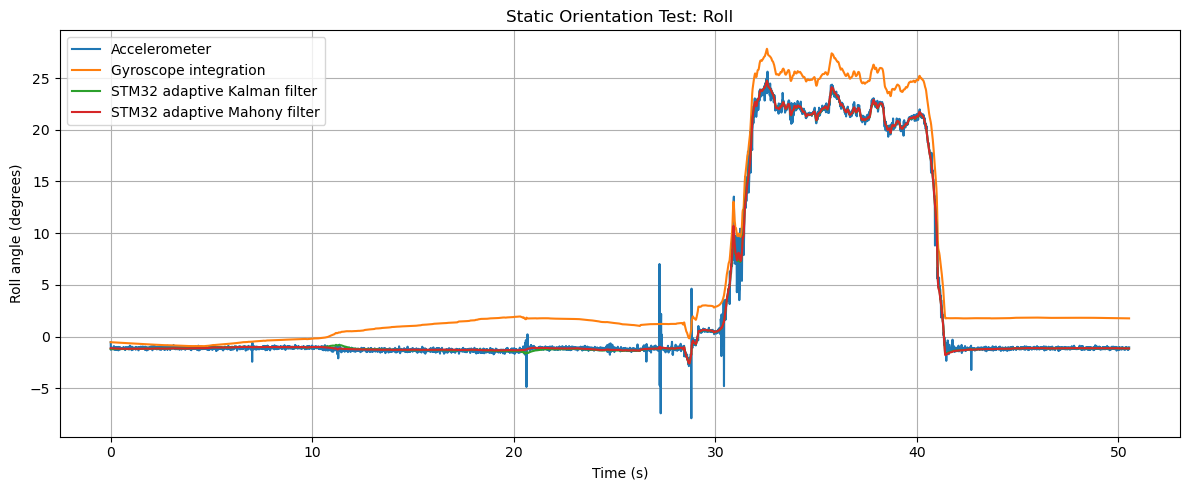

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    static_df["time_s"],
    static_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    static_df["time_s"],
    static_df["roll_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Static Orientation Test: Roll")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


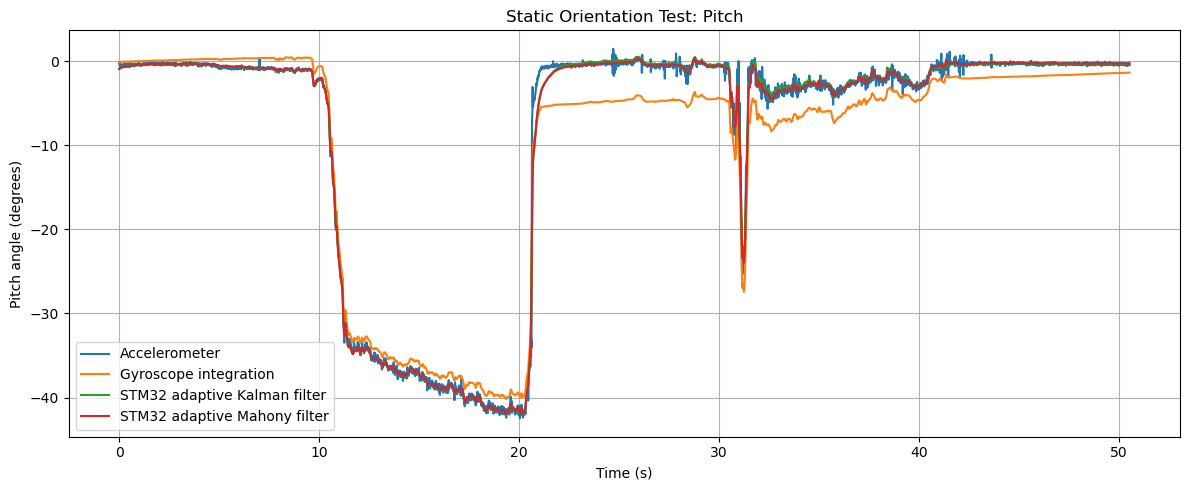

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    static_df["time_s"],
    static_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    static_df["time_s"],
    static_df["pitch_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Static Orientation Test: Pitch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Long Hold Test
exposes the gyro's weakness with bias accumulating over time

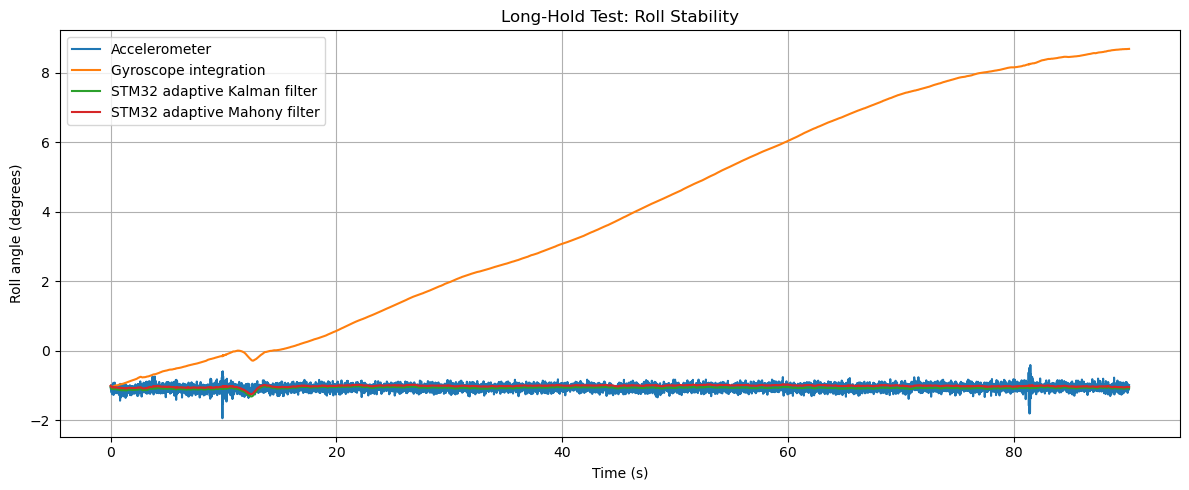

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    hold_df["time_s"],
    hold_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    hold_df["time_s"],
    hold_df["roll_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Long-Hold Test: Roll Stability")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


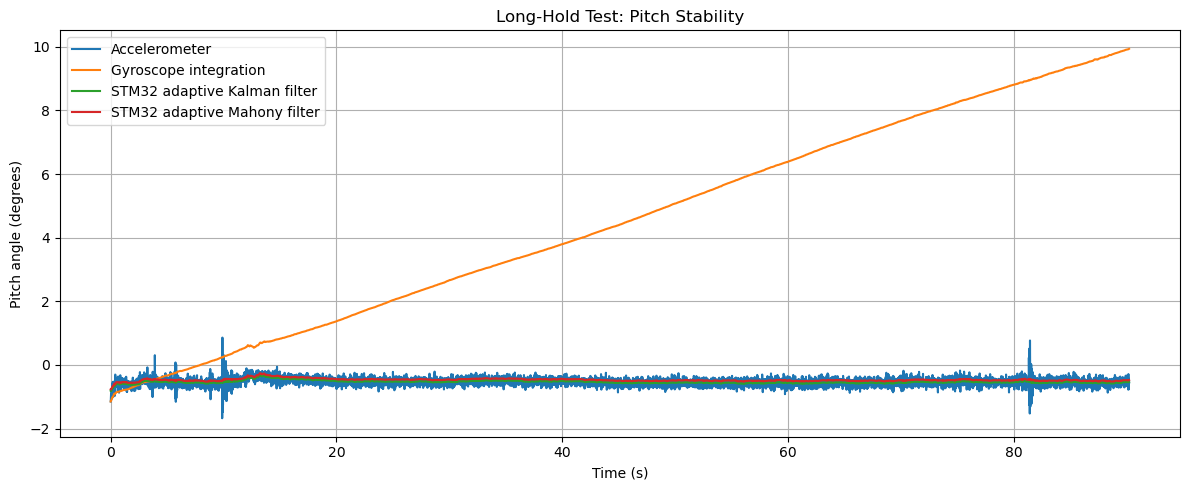

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    hold_df["time_s"],
    hold_df["pitch_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Long-Hold Test: Pitch Stability")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [33]:
# Finding mean angular velocity to compare with the onboard bias estimate.
skip_seconds = 5.0

bias_df = hold_df.loc[
    hold_df["time_s"] >= skip_seconds
]

gx_mean_dps = bias_df["gx_dps"].mean()
gy_mean_dps = bias_df["gy_dps"].mean()


## Horizontal Shake Test
exposes the accelerometer weakness by applying a non-gravitational acceleration

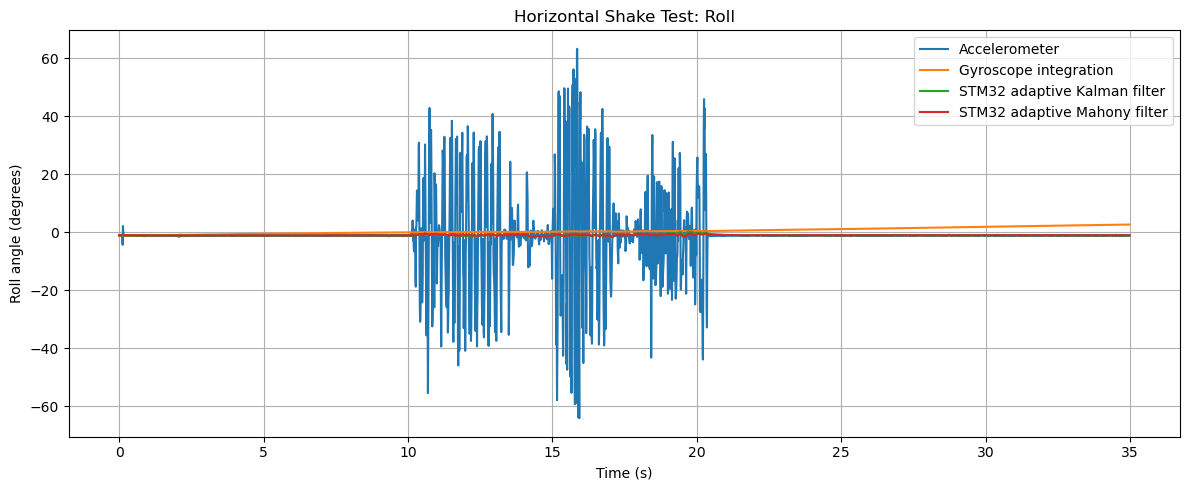

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    shake_df["time_s"],
    shake_df["roll_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["roll_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Roll angle (degrees)")
plt.title("Horizontal Shake Test: Roll")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


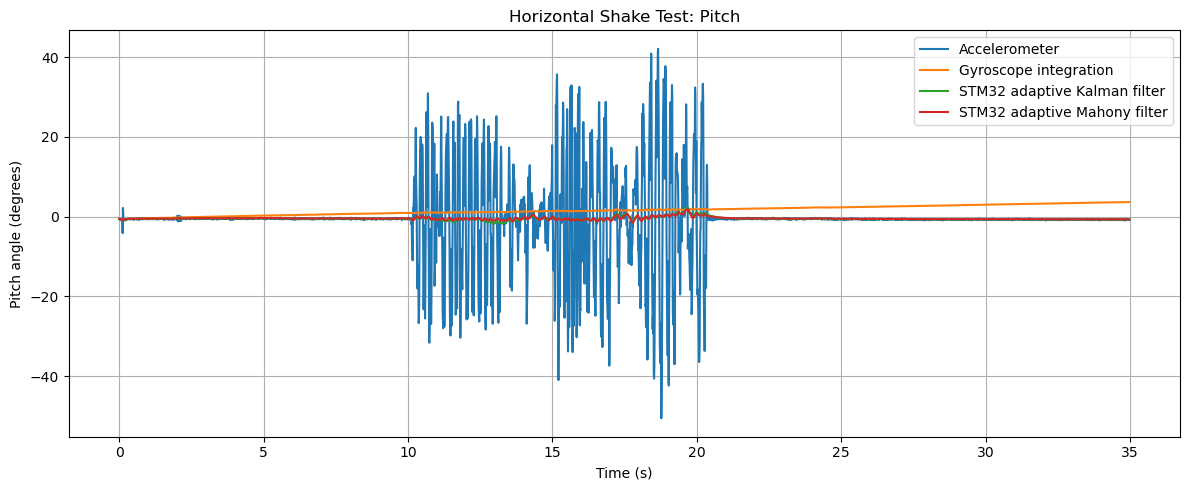

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_acc_deg"],
    label="Accelerometer"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_gyro_deg"],
    label="Gyroscope integration"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_kf_adaptive_deg"],
    label="STM32 adaptive Kalman filter"
)

plt.plot(
    shake_df["time_s"],
    shake_df["pitch_mahony_deg"],
    label="STM32 adaptive Mahony filter"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch angle (degrees)")
plt.title("Horizontal Shake Test: Pitch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
